In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [2]:
goog_data = yf.download('GOOG', start = '2001-01-01', end='2018-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
signals = pd.DataFrame(index=goog_data.index)

In [4]:
signals['short_ma'] = goog_data['Close'].rolling(window=40).mean()
signals['long_ma']  = goog_data['Close'].rolling(window=100).mean()

In [33]:
signal_list = []
for i in range(len(signals)):
    
    if pd.isna(signals['long_ma'].iloc[i]):
        signal_list.append(0)
        continue
    
    sma = signals['short_ma'].iloc[i]
    lma = signals['long_ma'].iloc[i]

    if sma > lma:
        signal_list.append(1)
    elif sma < lma:
        signal_list.append(-1)
    else:
        signal_list.append(0)


signals['signal'] = signal_list
signals['orders'] = signals['signal'].diff()

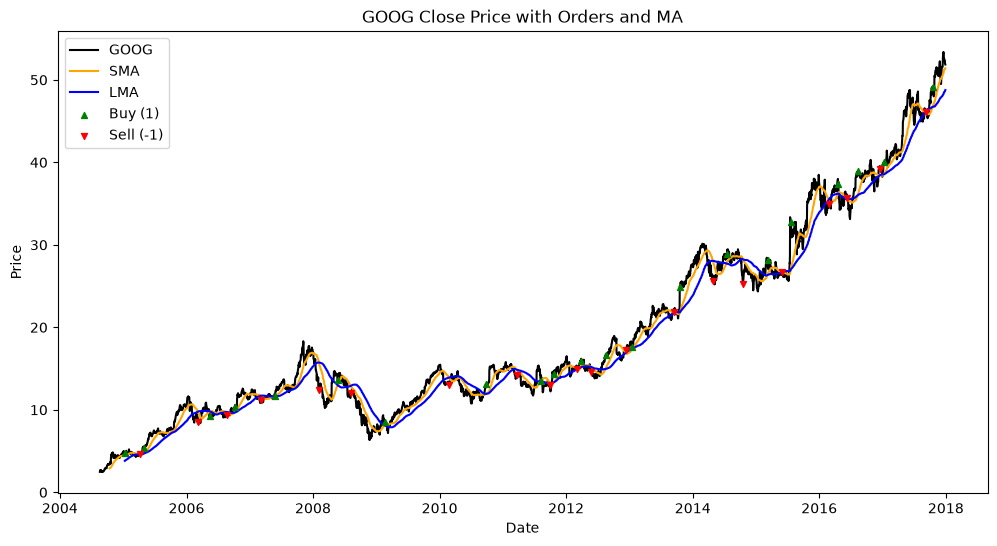

In [27]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(goog_data['Close'], label='GOOG', color='black')
ax.plot(signals['short_ma'], label ='SMA', color='orange')
ax.plot(signals['long_ma'], label='LMA',color='blue')

orders = signals['orders'].fillna(0)
buys = orders > 0
sells = orders < 0

ax.scatter(goog_data.index[buys], goog_data['Close'][buys], color='green', marker='^', s=18, label='Buy (1)', zorder=6)
ax.scatter(goog_data.index[sells], goog_data['Close'][sells], color='red', marker='v', s=18, label='Sell (-1)', zorder=6)

ax.set_title('GOOG Close Price with Orders and MA')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.show()

In [29]:
def update_position(prev_position, order, shares_per_signal=100):
    """
    Updates number of shares held based on today's order.
    """
    if pd.isna(order):
        order = 0

    return prev_position + shares_per_signal * order


def update_cash(prev_cash, order, price, shares_per_signal=100):
    """
    Updates cash after executing today's order.
    """
    if pd.isna(order):
        order = 0

    trade_shares = shares_per_signal * order
    return prev_cash - trade_shares * price


def compute_holdings(position, price):
    """
    Market value of current position.

    Long position: positive holdings.
    Short position: negative holdings.
    """
    return position * price


def compute_total_value(cash, holdings):
    """
    Total portfolio value.
    """
    return cash + holdings

In [30]:
initial_capital = 10_000
shares_per_signal = 100

# yfinance sometimes returns Close as a DataFrame instead of a Series
close_prices = goog_data["Close"]

if isinstance(close_prices, pd.DataFrame):
    close_prices = close_prices.iloc[:, 0]

portfolio_rows = []

prev_cash = initial_capital
prev_position = 0

for date in signals.index:
    price = close_prices.loc[date]
    order = signals.loc[date, "orders"]

    position = update_position(
        prev_position=prev_position,
        order=order,
        shares_per_signal=shares_per_signal
    )

    cash = update_cash(
        prev_cash=prev_cash,
        order=order,
        price=price,
        shares_per_signal=shares_per_signal
    )

    holdings = compute_holdings(position, price)
    total = compute_total_value(cash, holdings)

    portfolio_rows.append({
        "Date": date,
        "price": price,
        "signal": signals.loc[date, "signal"],
        "orders": order,
        "position": position,
        "holdings": holdings,
        "cash": cash,
        "total": total
    })

    prev_position = position
    prev_cash = cash

In [31]:
portfolio = pd.DataFrame(portfolio_rows)
portfolio = portfolio.set_index("Date")

portfolio.head()

,price,signal,orders,position,holdings,cash,total
Date,,,,,,,
2004-08-19,2.477291,0,NaN,0.0,0.0,10000.0,10000.0
2004-08-20,2.674062,0,0.0,0.0,0.0,10000.0,10000.0
2004-08-23,2.700974,0,0.0,0.0,0.0,10000.0,10000.0
2004-08-24,2.589133,0,0.0,0.0,0.0,10000.0,10000.0
2004-08-25,2.617030,0,0.0,0.0,0.0,10000.0,10000.0


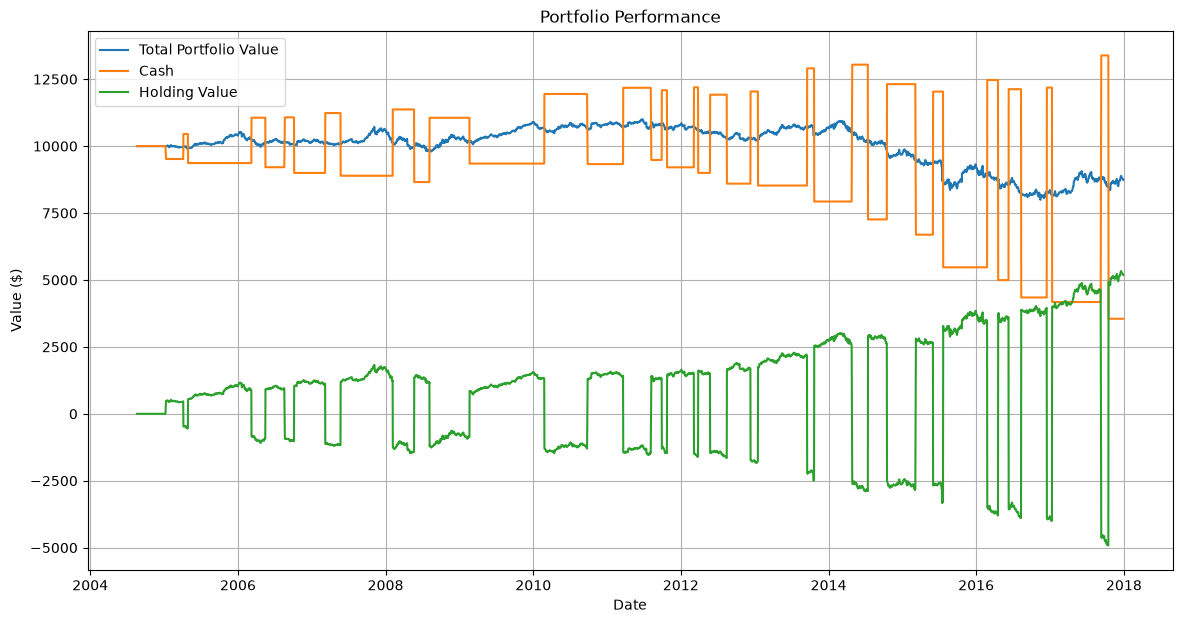

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(portfolio.index, portfolio["total"], label="Total Portfolio Value")
plt.plot(portfolio.index, portfolio["cash"], label="Cash")
plt.plot(portfolio.index, portfolio["holdings"], label="Holding Value")

plt.title("Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)

plt.show()